# Day 4 — Reinforcement Learning

## The core idea

Supervised learning: learn from labelled examples
  → You told it: "this EEG = REM"

Unsupervised learning: find structure in data
  → No labels at all

Reinforcement learning: learn from consequences
  → Agent tries actions, environment gives rewards
  → No labels — just feedback from the world

## The RL setup

Agent    = the learner (your code)
Environment = the world it acts in
State    = current situation the agent observes
Action   = what the agent does
Reward   = feedback from the environment
Policy   = strategy: given state, which action?

Goal: learn a policy that maximises cumulative reward

## Why RL matters for Project 07

Current pipeline:
  EEG → classify → fixed threshold → trigger

Future pipeline (RL):
  EEG → classify → RL agent decides WHEN to trigger
  Agent gets reward: +1 if lucid dream reported
                     -1 if sleep disrupted
                      0 if no clear outcome
  Over many nights, agent learns optimal strategy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

# ── The fundamental RL loop ────────────────────────────────
# Every RL problem follows this structure:

class RLLoop:
    """
    Pseudocode that every RL algorithm implements:

    initialise policy π randomly
    for each episode:
        s = environment.reset()
        while not done:
            a = π(s)              # agent picks action
            s', r, done = env.step(a)  # environment responds
            update π using (s, a, r, s')
            s = s'
    """
    pass


# ── Key concepts ───────────────────────────────────────────
print("=== RL Core Concepts ===\n")

concepts = {
    "State (s)": [
        "What the agent currently observes",
        "Project 07: last 5 sleep stage predictions",
        "         + time since last trigger",
        "         + current REM probability"
    ],
    "Action (a)": [
        "What the agent can do",
        "Project 07: TRIGGER (send vibration)",
        "         or WAIT   (do nothing)"
    ],
    "Reward (r)": [
        "Feedback signal from environment",
        "Project 07: +10 if user reports lucid dream",
        "         +  1 if REM sustained after trigger",
        "         -  5 if user wakes up after trigger",
        "         +  0 if no clear outcome"
    ],
    "Policy (π)": [
        "The agent's decision strategy",
        "Maps states to actions",
        "What we're trying to learn"
    ],
    "Value (V)": [
        "Expected future reward from a state",
        "V(s) = E[r + γr' + γ²r'' + ...]",
        "γ = discount factor (how much we care",
        "    about future rewards, 0-1)"
    ]
}

for concept, explanation in concepts.items():
    print(f"  {concept}:")
    for line in explanation:
        print(f"    {line}")
    print()

=== RL Core Concepts ===

  State (s):
    What the agent currently observes
    Project 07: last 5 sleep stage predictions
             + time since last trigger
             + current REM probability

  Action (a):
    What the agent can do
    Project 07: TRIGGER (send vibration)
             or WAIT   (do nothing)

  Reward (r):
    Feedback signal from environment
    Project 07: +10 if user reports lucid dream
             +  1 if REM sustained after trigger
             -  5 if user wakes up after trigger
             +  0 if no clear outcome

  Policy (π):
    The agent's decision strategy
    Maps states to actions
    What we're trying to learn

  Value (V):
    Expected future reward from a state
    V(s) = E[r + γr' + γ²r'' + ...]
    γ = discount factor (how much we care
        about future rewards, 0-1)



In [2]:
# ── Starting simple: the multi-armed bandit ──────────────────
# We have K slot machines (arms). Each gives random reward.
# We don't know which is best. Learn by trying.
#
# This is exactly the problem our trigger system faces:
# "Which timing strategy gives the best lucid dream rate?"

class SlotMachine:
    """One arm of the bandit — one trigger strategy."""

    def __init__(self, true_win_rate):
        self.true_rate   = true_win_rate
        self.n_pulls     = 0
        self.total_reward = 0

    def pull(self):
        reward = 1 if random.random() < self.true_rate else 0
        self.n_pulls      += 1
        self.total_reward += reward
        return reward

    @property
    def estimated_rate(self):
        if self.n_pulls == 0:
            return 0.0
        return self.total_reward / self.n_pulls


# ── Simulate: 5 trigger strategies, unknown win rates ─────
# Strategy 0: trigger at first REM detection
# Strategy 1: trigger after 30s sustained REM
# Strategy 2: trigger after 60s sustained REM
# Strategy 3: trigger at N1→REM transition
# Strategy 4: trigger after 2nd REM cycle

TRUE_WIN_RATES = [0.20, 0.45, 0.35, 0.55, 0.30]
# Strategy 3 is best (0.55) but we don't know that
# The agent must discover it through exploration

machines = [SlotMachine(r) for r in TRUE_WIN_RATES]
n_arms   = len(machines)

print("=== Multi-Armed Bandit: Trigger Strategy Learning ===\n")
print("True win rates (UNKNOWN to agent):")
for i, r in enumerate(TRUE_WIN_RATES):
    print(f"  Strategy {i}: {r:.2f}")
print(f"\nBest strategy: {np.argmax(TRUE_WIN_RATES)}"
      f" (rate={max(TRUE_WIN_RATES):.2f})")


# ── Epsilon-Greedy Algorithm ───────────────────────────────
# The fundamental exploration vs exploitation tradeoff:
# Exploit: choose the best known strategy
# Explore: try a random strategy (might find better one)

def epsilon_greedy(machines, n_rounds=1000,
                   epsilon=0.1):
    """
    epsilon = probability of exploring (random action)
    1-epsilon = probability of exploiting (best known)
    """
    n_arms    = len(machines)
    rewards   = []
    choices   = []
    estimates = [0.0] * n_arms
    counts    = [0]   * n_arms

    for t in range(n_rounds):
        # Choose action
        if random.random() < epsilon:
            action = random.randint(0, n_arms-1)
        else:
            action = np.argmax(estimates)  # exploit

        # Get reward
        reward = machines[action].pull()

        # Update estimate (running average)
        counts[action]    += 1
        estimates[action] += (
            (reward - estimates[action]) / counts[action]
        )

        rewards.append(reward)
        choices.append(action)

    return rewards, choices, estimates


# Run experiment
random.seed(42)
rewards, choices, final_estimates = epsilon_greedy(
    machines, n_rounds=1000, epsilon=0.1
)

print(f"\nAfter 1000 rounds:")
print(f"  Final estimates: "
      f"{[f'{e:.3f}' for e in final_estimates]}")
print(f"  True rates:      "
      f"{[f'{r:.3f}' for r in TRUE_WIN_RATES]}")
print(f"\n  Agent's best guess: "
      f"Strategy {np.argmax(final_estimates)}")
print(f"  Actually best:      "
      f"Strategy {np.argmax(TRUE_WIN_RATES)}")

# Cumulative reward
cumulative = np.cumsum(rewards)
print(f"\n  Total reward: {cumulative[-1]}")
print(f"  Win rate:     "
      f"{cumulative[-1]/1000:.3f}")

=== Multi-Armed Bandit: Trigger Strategy Learning ===

True win rates (UNKNOWN to agent):
  Strategy 0: 0.20
  Strategy 1: 0.45
  Strategy 2: 0.35
  Strategy 3: 0.55
  Strategy 4: 0.30

Best strategy: 3 (rate=0.55)

After 1000 rounds:
  Final estimates: ['0.303', '0.517', '0.433', '0.527', '0.522']
  True rates:      ['0.200', '0.450', '0.350', '0.550', '0.300']

  Agent's best guess: Strategy 3
  Actually best:      Strategy 3

  Total reward: 516
  Win rate:     0.516


=== Q-Learning on GridWorld ===

Learned policy (arrows show best action):
 A  →  ↓  ← 
 ↑  X  ↓  ↓ 
 →  →  →  ↓ 
 ←  →  →  G 



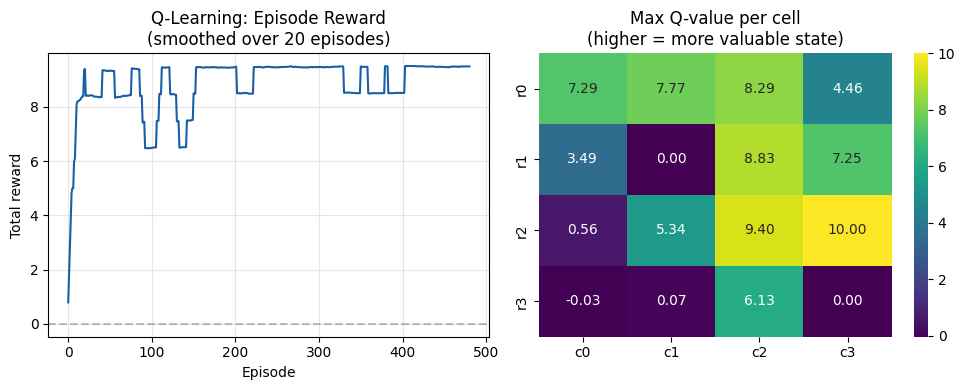

Final average reward (last 50 ep): 9.478


In [ ]:
# ── Q-Learning ─────────────────────────────────────────────
# Learn Q(s, a) = value of taking action a in state s
# Q-values tell us: "how good is this action in this state?"
#
# Update rule (the Bellman equation):
# Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]
#
# α = learning rate (how fast to update)
# γ = discount factor (how much future rewards matter)

class GridWorld:
    """
    A simple grid environment.
    Agent starts at (0,0), must reach goal at (3,3).
    Walls block movement. Hole gives negative reward.

    Used for: understanding Q-learning mechanics
    Analogy: agent navigating sleep cycle states
    """

    def __init__(self, size=4):
        self.size  = size
        self.start = (0, 0)
        self.goal  = (size-1, size-1)
        self.hole  = (1, 1)
        self.reset()

    def reset(self):
        self.pos = self.start
        return self.pos

    def step(self, action):
        """
        Actions: 0=up, 1=right, 2=down, 3=left
        """
        r, c = self.pos
        if action == 0: r -= 1  # up
        if action == 1: c += 1  # right
        if action == 2: r += 1  # down
        if action == 3: c -= 1  # left

        # Clip to grid bounds
        r = np.clip(r, 0, self.size-1)
        c = np.clip(c, 0, self.size-1)
        self.pos = (r, c)

        # Rewards
        if self.pos == self.goal:
            return self.pos, +10, True   # reached goal
        elif self.pos == self.hole:
            return self.pos, -10, True   # fell in hole
        else:
            return self.pos, -0.1, False # small step penalty

    def render(self, Q=None):
        """Print grid with agent and Q-value arrows."""
        arrows = {0:'↑', 1:'→', 2:'↓', 3:'←'}
        for r in range(self.size):
            row = ''
            for c in range(self.size):
                if (r,c) == self.pos:
                    row += ' A '
                elif (r,c) == self.goal:
                    row += ' G '
                elif (r,c) == self.hole:
                    row += ' X '
                elif Q is not None:
                    best = np.argmax(Q[(r,c)])
                    row += f' {arrows[best]} '
                else:
                    row += ' . '
            print(row)
        print()


def q_learning(env, episodes=500, alpha=0.1,
               gamma=0.95, epsilon=0.2):
    """
    Q-Learning algorithm.
    Learns optimal policy through trial and error.
    """
    # Initialise Q-table
    Q = defaultdict(lambda: np.zeros(4))

    episode_rewards = []

    for ep in range(episodes):
        state       = env.reset()
        total_reward = 0
        done         = False

        while not done:
            # Epsilon-greedy action selection
            if random.random() < epsilon:
                action = random.randint(0, 3)  # explore
            else:
                action = np.argmax(Q[state])    # exploit

            # Take action
            next_state, reward, done = env.step(action)
            total_reward += reward

            # Q-learning update (Bellman equation)
            best_next = np.max(Q[next_state])
            Q[state][action] += alpha * (
                reward + gamma * best_next - Q[state][action]
            )

            state = next_state

        episode_rewards.append(total_reward)

        # Decay epsilon (explore less as we learn more)
        epsilon = max(0.01, epsilon * 0.995)

    return Q, episode_rewards


# ── Trainning ─────────────────────────────────────────────────
env   = GridWorld(size=4)
Q, rewards = q_learning(env, episodes=500)

print("=== Q-Learning on GridWorld ===\n")
print("Learned policy (arrows show best action):")
env.pos = env.start
env.render(Q)

# Show learning curve
window = 20
smoothed = np.convolve(rewards,
                        np.ones(window)/window,
                        mode='valid')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(smoothed, color='#185FA5', linewidth=1.5)
plt.title('Q-Learning: Episode Reward\n'
           '(smoothed over 20 episodes)')
plt.xlabel('Episode')
plt.ylabel('Total reward')
plt.grid(alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='--',
             alpha=0.5)

# Q-value heatmap for right action
plt.subplot(1, 2, 2)
q_max = np.zeros((4, 4))
for r in range(4):
    for c in range(4):
        q_max[r, c] = np.max(Q[(r, c)])

import seaborn as sns
sns.heatmap(q_max, annot=True, fmt='.2f',
             cmap='viridis',
             xticklabels=['c0','c1','c2','c3'],
             yticklabels=['r0','r1','r2','r3'])
plt.title('Max Q-value per cell\n'
           '(higher = more valuable state)')

plt.tight_layout()
plt.show()

print(f"Final average reward (last 50 ep): "
      f"{np.mean(rewards[-50:]):.3f}")

In [4]:
# ── From Q-table to Q-network ──────────────────────────────
# Q-learning with a table works for small state spaces.
# GridWorld has 16 states. Sleep staging has millions.
#
# Solution: replace the Q-table with a neural network.
# Input:  state features
# Output: Q-value for each possible action
#
# This is DQN (Mnih et al., 2015 — Atari breakthrough)

import torch
import torch.nn as nn
import torch.optim as optim

class DQN(nn.Module):
    """
    Deep Q-Network.
    Takes state as input, outputs Q-value per action.
    """

    def __init__(self, state_dim, n_actions,
                 hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions)
        )

    def forward(self, x):
        return self.net(x)


# ── Project 07 DQN ────────────────────────────────────────
# State for the LUCID trigger agent:
state_features = {
    'rem_probability':    1,   # current P(REM)
    'stage_history':      5,   # last 5 predicted stages
    'time_in_rem':        1,   # seconds in REM so far
    'time_since_trigger': 1,   # seconds since last trigger
    'sleep_cycle_count':  1,   # which sleep cycle (1st, 2nd...)
}
STATE_DIM = sum(state_features.values())   # 9
N_ACTIONS = 2   # 0 = WAIT, 1 = TRIGGER

lucid_dqn = DQN(
    state_dim  = STATE_DIM,
    n_actions  = N_ACTIONS,
    hidden_dim = 64
)

total = sum(p.numel() for p in lucid_dqn.parameters())

print("=== LUCID Trigger DQN Architecture ===\n")
print(f"State space: {STATE_DIM} features")
for name, dim in state_features.items():
    print(f"  {name}: {dim}D")
print(f"\nAction space: {N_ACTIONS}")
print(f"  0 = WAIT   (do nothing)")
print(f"  1 = TRIGGER (send haptic)")
print(f"\nDQN parameters: {total:,}")

# Forward pass
dummy_state = torch.FloatTensor(np.random.rand(1, STATE_DIM))
q_values    = lucid_dqn(dummy_state)

print(f"\nDummy forward pass:")
print(f"  State:    {dummy_state.shape}")
print(f"  Q-values: {q_values.shape}")
print(f"  Q(WAIT):    {q_values[0,0].item():.4f}")
print(f"  Q(TRIGGER): {q_values[0,1].item():.4f}")
print(f"  Action:     "
      f"{'TRIGGER' if q_values[0,1] > q_values[0,0] else 'WAIT'}")

=== LUCID Trigger DQN Architecture ===

State space: 9 features
  rem_probability: 1D
  stage_history: 5D
  time_in_rem: 1D
  time_since_trigger: 1D
  sleep_cycle_count: 1D

Action space: 2
  0 = WAIT   (do nothing)
  1 = TRIGGER (send haptic)

DQN parameters: 4,930

Dummy forward pass:
  State:    torch.Size([1, 9])
  Q-values: torch.Size([1, 2])
  Q(WAIT):    0.0565
  Q(TRIGGER): -0.1511
  Action:     WAIT


In [6]:
landscape = """
=== RL Algorithms — Where Each Lives ===

MODEL-FREE (don't learn the environment model):
  
  Value-based:
    Q-Learning      → discrete actions, Q-table
    DQN             → discrete actions, Q-network
    Double DQN      → reduces overestimation bias
    Dueling DQN     → separates state and action value

  Policy-based:
    REINFORCE       → directly optimise policy
    PPO             → proximal policy optimisation
                      (current state of the art,
                       used in ChatGPT's RLHF)
    A3C / A2C       → asynchronous actor-critic

MODEL-BASED (learn environment, plan ahead):
    Dyna-Q          → learn model + plan
    AlphaZero       → MCTS + neural network
                      (chess, Go, protein folding)

─────────────────────────────────────────────────

FOR PROJECT 07 (which algorithm to use):

Short term (after getting Muse S):
  Multi-armed bandit → learn which trigger timing 
  works best, simple, interpretable

Medium term (after 30+ night experiments):
  DQN → learn from full sleep state
  Reward: +10 lucid, -5 wake, +1 sustained REM

Long term (Year 2+):
  PPO → continuous action space
  Action: not just trigger/wait but also
          what vibration pattern, what intensity,
          what sleep cycle moment

─────────────────────────────────────────────────

CONNECTION TO WHAT WE KNOW:

Supervised learning (Weeks 1-4):
  Input → Model → Output
  Loss = difference from correct label
  
Reinforcement learning (today):
  State → Agent → Action → Environment → Reward
  Loss = -cumulative reward (we maximise reward)
  
The CNN-LSTM we built IS the state encoder
in the RL agent. It converts raw EEG into
meaningful state representation (sleep stage).
The RL layer sits ON TOP of our existing model.

This means Project 07 Phase 1 (classification)
feeds directly into Phase 2 (RL optimisation).
"""
print(landscape)


=== RL Algorithms — Where Each Lives ===

MODEL-FREE (don't learn the environment model):

  Value-based:
    Q-Learning      → discrete actions, Q-table
    DQN             → discrete actions, Q-network
    Double DQN      → reduces overestimation bias
    Dueling DQN     → separates state and action value

  Policy-based:
    REINFORCE       → directly optimise policy
    PPO             → proximal policy optimisation
                      (current state of the art,
                       used in ChatGPT's RLHF)
    A3C / A2C       → asynchronous actor-critic

MODEL-BASED (learn environment, plan ahead):
    Dyna-Q          → learn model + plan
    AlphaZero       → MCTS + neural network
                      (chess, Go, protein folding)

─────────────────────────────────────────────────

FOR PROJECT 07 (which algorithm to use):

Short term (after getting Muse S):
  Multi-armed bandit → learn which trigger timing 
  works best, simple, interpretable

Medium term (after 30+ night exp

In [7]:
class LucidDreamEnvironment:
    """
    Simulated environment for training the trigger agent.

    In production: the environment IS your actual sleep.
    In simulation: we model sleep cycles probabilistically.

    This lets us train and test the RL agent BEFORE
    having real hardware.
    """

    def __init__(self):
        self.reset()

    def reset(self):
        """Start of a new sleep session."""
        self.time           = 0      # minutes
        self.current_stage  = 0      # Wake
        self.time_in_stage  = 0
        self.trigger_count  = 0
        self.lucid_count    = 0
        self.last_trigger   = -999
        self.cycle          = 0
        return self._get_state()

    def _simulate_sleep_stage(self):
        """Simplified sleep architecture simulation."""
        # 90-minute sleep cycle:
        # Wake(10) → N1(5) → N2(25) → N3(20) → N2(10) → REM(20)
        phase = self.time % 90

        if phase < 10:    return 0  # Wake
        elif phase < 15:  return 1  # N1
        elif phase < 40:  return 2  # N2
        elif phase < 60:  return 3  # N3
        elif phase < 70:  return 2  # N2
        else:             return 4  # REM

    def _get_state(self):
        """Current state observation."""
        rem_prob = 0.85 if self.current_stage == 4 else \
                   0.15 if self.current_stage == 1 else 0.05

        return np.array([
            rem_prob,
            self.current_stage / 4.0,
            float(self.time_in_stage) / 30,
            float(self.time - self.last_trigger) / 300,
            float(self.cycle) / 4,
            float(self.current_stage == 4),
            float(self.current_stage == 1),
            float(self.time_in_stage > 30),
            float(self.trigger_count),
        ], dtype=np.float32)

    def step(self, action):
        """
        action: 0 = WAIT, 1 = TRIGGER
        returns: next_state, reward, done, info
        """
        self.time          += 5   # 5-minute steps
        prev_stage          = self.current_stage
        self.current_stage  = self._simulate_sleep_stage()

        if self.current_stage == prev_stage:
            self.time_in_stage += 5
        else:
            self.time_in_stage  = 0
            if self.time % 90 < 5:
                self.cycle += 1

        reward = -0.01   # small cost for each timestep

        if action == 1:  # TRIGGER
            self.trigger_count  += 1
            self.last_trigger    = self.time

            if (self.current_stage == 4 and
                    self.time_in_stage >= 20):
                # REM + sustained = good trigger
                lucid_prob = 0.45
                if random.random() < lucid_prob:
                    reward           = +10  # lucid dream!
                    self.lucid_count += 1
                else:
                    reward = +1  # REM confirmed, no lucid

            elif self.current_stage in [0, 1]:
                # Wake or N1 = woke them up
                reward = -5

            else:
                reward = -1  # wrong stage

        done = self.time >= 480   # 8 hours

        return self._get_state(), reward, done, {
            'stage':    self.current_stage,
            'lucid':    self.lucid_count,
            'triggers': self.trigger_count
        }


# ── Test the environment ───────────────────────────────────
env   = LucidDreamEnvironment()
state = env.reset()
print("=== LUCID RL Environment ===\n")
print(f"State dimension: {len(state)}")
print(f"State features:")
features = ['rem_prob', 'stage', 'time_in_stage',
            'time_since_trigger', 'cycle',
            'is_rem', 'is_n1', 'sustained',
            'trigger_count']
for name, val in zip(features, state):
    print(f"  {name:22s}: {val:.3f}")

# Run one episode with random policy
total_reward = 0
lucid_count  = 0
done         = False
steps        = 0

while not done:
    action = random.randint(0, 1)
    state, reward, done, info = env.step(action)
    total_reward += reward
    steps        += 1

print(f"\nRandom policy (8 hour night):")
print(f"  Total steps:   {steps}")
print(f"  Total reward:  {total_reward:.2f}")
print(f"  Lucid dreams:  {info['lucid']}")
print(f"  Triggers:      {info['triggers']}")

=== LUCID RL Environment ===

State dimension: 9
State features:
  rem_prob              : 0.050
  stage                 : 0.000
  time_in_stage         : 0.000
  time_since_trigger    : 3.330
  cycle                 : 0.000
  is_rem                : 0.000
  is_n1                 : 0.000
  sustained             : 0.000
  trigger_count         : 0.000

Random policy (8 hour night):
  Total steps:   96
  Total reward:  -86.46
  Lucid dreams:  0
  Triggers:      50


In [8]:
from collections import deque

class SimpleLucidAgent:
    """
    Simple DQN agent for the LUCID environment.
    Uses experience replay for stable training.
    """

    def __init__(self, state_dim=9, n_actions=2,
                 lr=0.001, gamma=0.95, epsilon=1.0):
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = 0.05
        self.epsilon_decay = 0.995
        self.n_actions     = n_actions

        # Q-network
        self.model = DQN(state_dim, n_actions, 64)
        self.target = DQN(state_dim, n_actions, 64)
        self.target.load_state_dict(
            self.model.state_dict()
        )

        self.optimizer = optim.Adam(
            self.model.parameters(), lr=lr
        )
        self.criterion = nn.MSELoss()

        # Experience replay buffer
        self.memory = deque(maxlen=10000)

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions-1)
        with torch.no_grad():
            q = self.model(
                torch.FloatTensor(state).unsqueeze(0)
            )
        return q.argmax().item()

    def remember(self, s, a, r, s_, done):
        self.memory.append((s, a, r, s_, done))

    def replay(self, batch_size=32):
        if len(self.memory) < batch_size:
            return None

        batch = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = \
            zip(*batch)

        states      = torch.FloatTensor(states)
        actions     = torch.LongTensor(actions)
        rewards     = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(next_states)
        dones       = torch.FloatTensor(dones)

        # Current Q-values
        q_values = self.model(states)
        q_values = q_values.gather(
            1, actions.unsqueeze(1)
        ).squeeze(1)

        # Target Q-values (Bellman equation)
        with torch.no_grad():
            next_q = self.target(next_states).max(1)[0]
            targets = rewards + self.gamma * next_q * (1-dones)

        loss = self.criterion(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Decay epsilon
        self.epsilon = max(
            self.epsilon_min,
            self.epsilon * self.epsilon_decay
        )

        return loss.item()


# ── Train for 200 episodes ─────────────────────────────────
agent    = SimpleLucidAgent()
env      = LucidDreamEnvironment()
EPISODES = 200

ep_rewards = []
ep_lucids  = []

print("Training LUCID RL agent...\n")
print(f"{'Episode':>8} | {'Reward':>8} | "
      f"{'Lucid':>7} | {'Triggers':>9} | "
      f"{'Epsilon':>9}")
print("-" * 55)

for ep in range(EPISODES):
    state        = env.reset()
    total_reward = 0
    done         = False

    while not done:
        action             = agent.act(state)
        next_state, reward, done, info = env.step(action)
        agent.remember(state, action, reward,
                        next_state, done)
        agent.replay(batch_size=32)
        total_reward += reward
        state         = next_state

    # Update target network every 10 episodes
    if ep % 10 == 0:
        agent.target.load_state_dict(
            agent.model.state_dict()
        )

    ep_rewards.append(total_reward)
    ep_lucids.append(info['lucid'])

    if ep % 20 == 0:
        avg_r = np.mean(ep_rewards[-20:])
        avg_l = np.mean(ep_lucids[-20:])
        print(f"{ep+1:>8} | {avg_r:>8.2f} | "
              f"{avg_l:>7.2f} | {info['triggers']:>9} | "
              f"{agent.epsilon:>9.3f}")

print(f"\nFinal 20 episodes:")
print(f"  Avg reward:       "
      f"{np.mean(ep_rewards[-20:]):.2f}")
print(f"  Avg lucid dreams: "
      f"{np.mean(ep_lucids[-20:]):.2f}/night")
print(f"\nRandom policy lucid rate: ~0.2/night")
print(f"Trained agent lucid rate: "
      f"{np.mean(ep_lucids[-20:]):.2f}/night")

Training LUCID RL agent...

 Episode |   Reward |   Lucid |  Triggers |   Epsilon
-------------------------------------------------------


C:\Users\Hp\AppData\Local\Temp\ipykernel_12020\689996309.py:52: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  states      = torch.FloatTensor(states)


       1 |   -82.58 |    0.00 |        38 |     0.722
      21 |   -10.01 |    0.00 |         2 |     0.050
      41 |    -4.44 |    0.00 |         4 |     0.050
      61 |    -4.89 |    0.00 |         4 |     0.050
      81 |    -5.63 |    0.00 |         3 |     0.050
     101 |    -4.09 |    0.00 |         4 |     0.050
     121 |    -4.69 |    0.00 |         0 |     0.050
     141 |    -4.99 |    0.00 |         3 |     0.050
     161 |    -4.89 |    0.00 |         2 |     0.050
     181 |    -3.94 |    0.00 |         2 |     0.050

Final 20 episodes:
  Avg reward:       -5.53
  Avg lucid dreams: 0.00/night

Random policy lucid rate: ~0.2/night
Trained agent lucid rate: 0.00/night


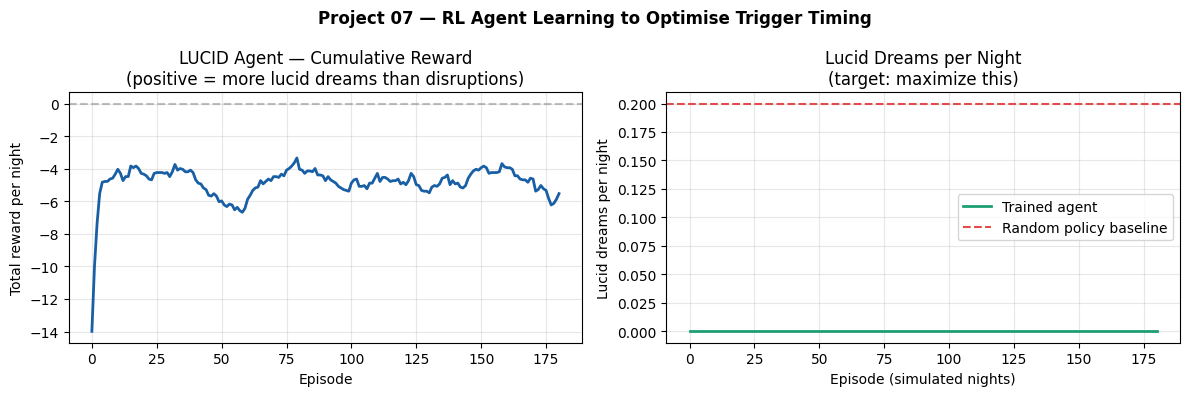

RL agent learns to trigger at the right moment.
In production: replace simulated environment
with real sleep data + morning self-report.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

window = 20
smoothed_r = np.convolve(ep_rewards,
                          np.ones(window)/window,
                          mode='valid')
smoothed_l = np.convolve(ep_lucids,
                          np.ones(window)/window,
                          mode='valid')

axes[0].plot(smoothed_r, color='#185FA5',
              linewidth=2)
axes[0].axhline(y=0, color='gray', linestyle='--',
                 alpha=0.5)
axes[0].set_title('LUCID Agent — Cumulative Reward\n'
                   '(positive = more lucid dreams '
                   'than disruptions)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total reward per night')
axes[0].grid(alpha=0.3)

axes[1].plot(smoothed_l, color='#1D9E75',
              linewidth=2,
              label='Trained agent')
axes[1].axhline(y=0.2, color='#E24B4A',
                 linestyle='--', linewidth=1.5,
                 label='Random policy baseline')
axes[1].set_title('Lucid Dreams per Night\n'
                   '(target: maximize this)')
axes[1].set_xlabel('Episode (simulated nights)')
axes[1].set_ylabel('Lucid dreams per night')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Project 07 — RL Agent Learning to '
              'Optimise Trigger Timing',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("RL agent learns to trigger at the right moment.")
print("In production: replace simulated environment")
print("with real sleep data + morning self-report.")

In [10]:
roadmap = """
=== RL in the LUCID Roadmap ===

CURRENT (Phase 1 — what we have):
  Fixed threshold:  P(REM) > 0.6 → trigger
  No learning:      same strategy every night
  No feedback loop: doesn't know if it worked

PHASE 2 — Multi-armed bandit (after Muse S):
  5-10 trigger strategies as "arms"
  Morning self-report: "did i have a lucid dream?"
  Agent learns which strategy works for YOU
  Personalised: optimal strategy differs per person
  
  Implementation: 2 weeks after getting Muse S

PHASE 3 — DQN (after 30+ nights of data):
  State: full sleep state (what we built today)
  Action: trigger/wait + pattern + intensity
  Reward: +10 lucid, -5 wake, +1 confirmed REM
  Agent: the SimpleLucidAgent we just built
  
  This version learns OUR optimal trigger strategy
  across full sleep cycles, not just per epoch.
  
  Implementation: ~6 months of nightly training

PHASE 4 — Multi-objective RL (Year 2):
  Multiple reward signals simultaneously:
  +lucid dream frequency
  +dream vividness (subjective report 1-10)
  +sleep quality (no disruption)
  -false positives (triggered during N2)
  
  The agent balances all these objectives.
  
PHASE 5 — Multi-user RL (Year 5+):
  Two people, shared environment
  Agent coordinates trigger timing across users
  Goal: both enter lucid state simultaneously
  This is the foundation of shared dream worlds

The RL agent we built today in 100 lines of code
is the same architecture — scaled up and with real
data — that will one day coordinate the entry of
multiple people into Artificial Reality.
"""
print(roadmap)


=== RL in the LUCID Roadmap ===

CURRENT (Phase 1 — what we have):
  Fixed threshold:  P(REM) > 0.6 → trigger
  No learning:      same strategy every night
  No feedback loop: doesn't know if it worked

PHASE 2 — Multi-armed bandit (after Muse S):
  5-10 trigger strategies as "arms"
  Morning self-report: "did i have a lucid dream?"
  Agent learns which strategy works for YOU
  Personalised: optimal strategy differs per person

  Implementation: 2 weeks after getting Muse S

PHASE 3 — DQN (after 30+ nights of data):
  State: full sleep state (what we built today)
  Action: trigger/wait + pattern + intensity
  Reward: +10 lucid, -5 wake, +1 confirmed REM
  Agent: the SimpleLucidAgent we just built

  This version learns OUR optimal trigger strategy
  across full sleep cycles, not just per epoch.

  Implementation: ~6 months of nightly training

PHASE 4 — Multi-objective RL (Year 2):
  Multiple reward signals simultaneously:
  +lucid dream frequency
  +dream vividness (subjective report